> **Purpose:** Partition imbalance η per tree, for the two operators, on 1000 Kingman + 1000 birth–death trees. Which split each operator picks, and whether it is a real tree edge.
> **Data:** generated (Kingman and birth–death, n=1000, L=10⁴)

# η by operator and tree model

Two thousand trees — 1000 Kingman, 1000 birth–death — each with `n = 1000` leaves and
`L = 10⁴` sites. For each tree, read a bipartition off each operator and record:

| | vector | rule |
|---|---|---|
| **`L(S)`** | Fiedler of `Deg(S) − S` | k-means on the entries |
| **`B`** | leading-\|λ\| eigenvector of `H D H`, `D = −log S` | sign |

- **η** = larger clan / smaller clan. η = 1 is a perfectly even split; η = 999 is one leaf
  against the rest.
- **valid** = the partition is a genuine single-edge bipartition of the true tree. An
  operator that returns a *stable* split which is not an edge has recovered nothing.

Birth–death trees are far more imbalanced than Kingman trees, which is where the validity
gate has a chance to bind.

Compute is `analysis/utils/eta_screen.py` (~15 min per model on 6 workers, cached and
resumable); this notebook loads the caches and plots.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FixedFormatter, FixedLocator

_root = Path.cwd()
while not (_root / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

from analysis.utils.eta_screen import run_eta_screen
from src.utils.tree_ids import build_ids

N, SEQ_LEN, COUNT = 1000, 10_000, 1000
MODELS = [("kingman", "Kingman"), ("bd", "birth-death")]
ARMS = [("S", r"$L(S)$, k-means"), ("B", r"$B=H\mathcal{D}H$, sign")]
CDIR = _root / "analysis" / "notebooks_cache" / "eta_by_operator"

frames = []
for model, _ in MODELS:
    ids = build_ids(models=[model], n_values=[N], per_cell=COUNT)
    rows = run_eta_screen(ids, CDIR / f"{model}_n{N}_L{SEQ_LEN}.npz",
                          seq_len=SEQ_LEN, workers=6)
    f = pd.DataFrame([r for r in rows if "error" not in r])
    f["model"] = model
    frames.append(f)
df = pd.concat(frames, ignore_index=True)
print(f"\n{len(df)} trees total, n={N}, L={SEQ_LEN}")
df.groupby("model").size()

cache: 1000 rows in kingman_n1000_L10000.npz
nothing to do -- all ids cached
cache: 1000 rows in bd_n1000_L10000.npz
nothing to do -- all ids cached

2000 trees total, n=1000, L=10000


model
bd         1000
kingman    1000
dtype: int64

In [2]:
summary = []
for model, mname in MODELS:
    d = df[df.model == model]
    for tag, aname in ARMS:
        e, v = d[f"eta_{tag}"], d[f"valid_{tag}"]
        summary.append({
            "model": mname, "operator": aname,
            "valid": f"{int(v.sum())}/{len(d)}",
            "valid %": round(100 * v.mean(), 1),
            "median eta": round(float(e.median()), 2),
            "90th pct": round(float(e.quantile(0.90)), 1),
            "max eta": round(float(e.max()), 1),
        })
pd.DataFrame(summary).set_index(["model", "operator"])

valid  valid %  median eta  90th pct  \
model       operator                                                           
Kingman     $L(S)$, k-means          996/1000     99.6        3.00      20.8   
            $B=H\mathcal{D}H$, sign  986/1000     98.6        1.85       4.6   
birth-death $L(S)$, k-means          996/1000     99.6        3.08      25.4   
            $B=H\mathcal{D}H$, sign  555/1000     55.5        1.53       2.8   

                                     max eta  
model       operator                          
Kingman     $L(S)$, k-means            499.0  
            $B=H\mathcal{D}H$, sign     24.6  
birth-death $L(S)$, k-means            999.0  
            $B=H\mathcal{D}H$, sign      5.3

## What the two operators actually read

The screen keeps scalars only, so this cell rebuilds **one** tree (`make_generated` is
deterministic in the tree id) and draws it **twice** — once per operator — with its
eigenvector alongside. Each copy is the same tree, laid out from its own patristic
distances; what changes is the colouring, which is the split that operator read off. A
clade is blue or orange when every leaf below it falls on one side, grey when it straddles
the cut, so a partition is a real tree edge exactly when the grey reduces to a single path
to the root.

`TREE_ID = None` picks the Kingman tree with the largest disagreement; set it to any
`df.tree` value to look at another. Diagnostic — writes no figure asset.

In [3]:
# The screen above stores scalars only, so rebuild ONE tree and look at the two
# vectors the two arms actually read. make_generated is deterministic in the id,
# and every step below mirrors screen_one() in analysis/utils/eta_screen.py.
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

from analysis.utils.eta_screen import MIN_SPLIT, _eta
from src.core.utils import compute_fiedler_from_laplacian, compute_laplacian
from src.models.generated_trees import make_generated
from src.runners.p_sweep_inner import _kmeans_bipartition
from src.utils.griffing import griffing_centered, griffing_leading_eigvec
from src.utils.operator_comparison import patristic_distance_matrix
from src.utils.partition_validity import check_partition_valid_in_tree
from src.utils.screening import _tree_leaf_index

TREE_ID = None                       # None -> the Kingman tree where the two arms disagree most
COL_A, COL_B, COL_MIX = "#1d4ed8", "#d97706", "#b8bcc4"   # clan A / clan B / mixed clade


def orient(v, part):
    """Display convention: clan B (part == True) is the minority side.

    Flipping v and part together is the same bipartition, so eta and validity are
    unchanged. They MUST flip together -- for arm B the mask *is* sign(v), so for
    that arm this also puts the minority clan on the positive side.
    """
    return (-v, ~part) if part.sum() > part.size / 2 else (v, part)


def link_colors(Z, mask):
    """Colour every merge in ``Z`` by the clan of the leaves below it.

    A clade is COL_A or COL_B when all of its leaves are on one side of the
    bipartition and COL_MIX when they are not, so a partition that IS a tree edge
    shows as two monochrome subtrees joined by a single grey path to the root.
    ``mask`` must be in the linkage's own leaf order, i.e. tree-leaf order.
    """
    n_b, total, cols = list(mask.astype(int)), [1] * mask.size, {}
    for i, (a, b) in enumerate(Z[:, :2].astype(int)):
        n_b.append(n_b[a] + n_b[b])
        total.append(total[a] + total[b])
        j = i + mask.size
        cols[j] = COL_B if n_b[j] == total[j] else (COL_A if n_b[j] == 0 else COL_MIX)
    return lambda k: cols.get(k, COL_MIX)


if TREE_ID is None:
    k = df[df.model == "kingman"]
    TREE_ID = k["tree"].iloc[int(np.abs(np.log(k.eta_S / k.eta_B)).values.argmax())]
row = df[df.tree == TREE_ID].iloc[0]
print(f"{TREE_ID}:  eta_S={row.eta_S:.2f} (valid={row.valid_S})   "
      f"eta_B={row.eta_B:.2f} (valid={row.valid_B})")

S, labels, tree, D = make_generated(TREE_ID, seq_len=SEQ_LEN)
sidx = _tree_leaf_index(tree, labels)          # labels order -> tree-leaf order

v_S = compute_fiedler_from_laplacian(compute_laplacian(S))
v_S, part_S = orient(v_S, np.asarray(_kmeans_bipartition(v_S, MIN_SPLIT)).astype(bool))
v_B = griffing_leading_eigvec(D, solver="lm_k1")
v_B, part_B = orient(v_B, v_B >= 0)

# the exhibit is only worth looking at if it reproduces the screened row
for tag, part in (("S", part_S), ("B", part_B)):
    assert np.isclose(_eta(part), row[f"eta_{tag}"]), tag
    assert check_partition_valid_in_tree(tree, part[sidx]) == row[f"valid_{tag}"], tag
agree = float(np.mean(part_S == part_B))
print(f"self-check OK;  leaf-level agreement between the two splits: "
      f"{max(agree, 1 - agree):.1%}")

# Leaf order for every exhibit below: the dendrogram's, so a clan of the true tree
# is a contiguous block of rows/columns instead of scatter.
Z = hierarchy.linkage(squareform(patristic_distance_matrix(tree), checks=False),
                      method="average")
leaf_order = hierarchy.leaves_list(Z)          # tree-leaf order -> bottom-to-top on screen
perm = sidx[leaf_order]                        # labels order -> display order
n_leaf = int(v_S.size)
y = np.arange(n_leaf) * 10 + 5                 # scipy puts leaf i at 10i+5


kingman_n1000_445:  eta_S=499.00 (valid=True)   eta_B=1.02 (valid=True)
self-check OK;  leaf-level agreement between the two splits: 50.7%


### The matrices the vectors come from

`S`, its Laplacian, the distance `D = -log S` and Griffing's centred `B = HDH`,
 on the same tree and in the same leaf order as the plots below. **Each panel is
 scaled separately** -- their ranges differ by orders of magnitude, so a shared
 colour scale would be uninformative; the sub-title of each panel states the norm
 it uses.


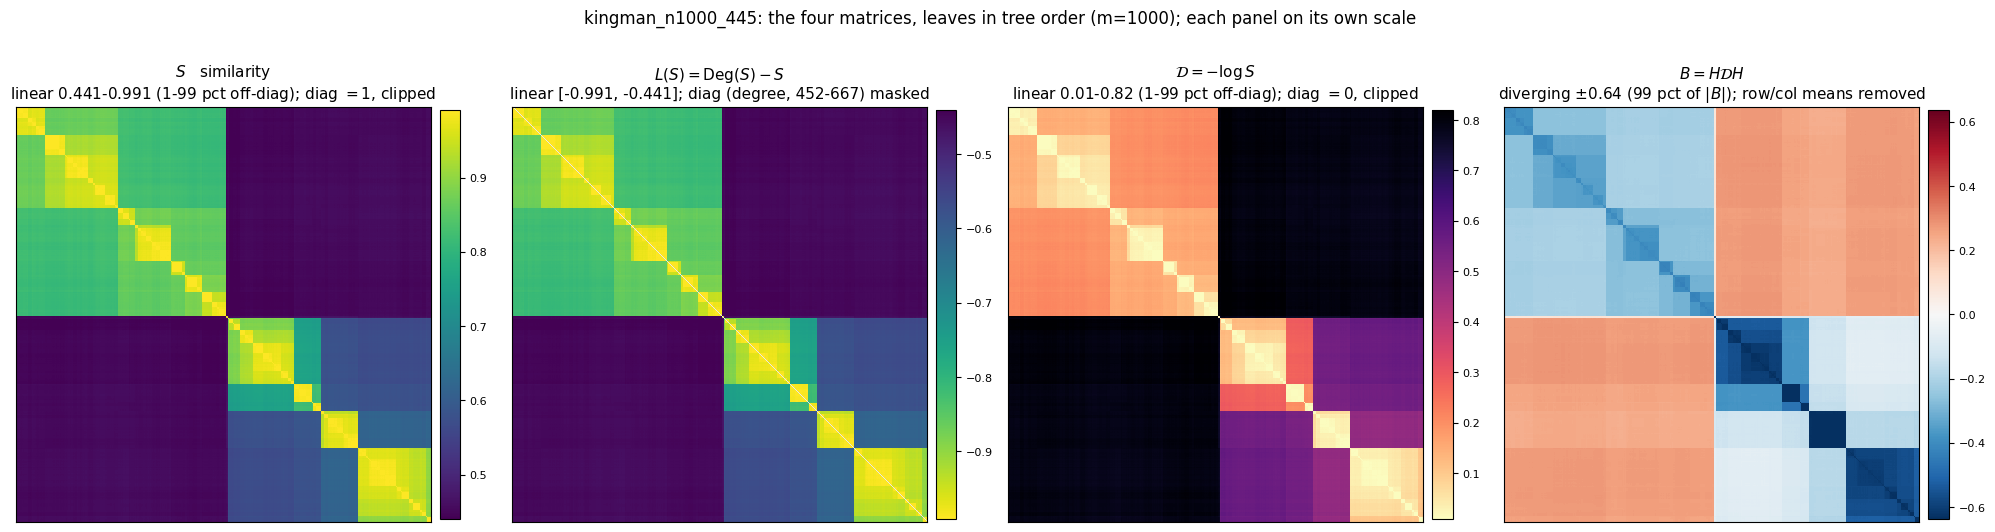

 S  min=+0.4341  max=+1  off-diag mean=+0.6152  sd=0.1934
 L  min=-1  max=-0.4341  off-diag mean=-0.6152  sd=0.1934
 D  min=-0  max=+0.8344  off-diag mean=+0.532  sd=0.2982
 B  min=-1.056  max=+0.2854  off-diag mean=+0.000532  sd=0.2842


In [4]:
# Before the vectors: the four operators themselves, same tree, same leaf order,
# so a clan of the true tree is a contiguous block. Each panel gets its OWN norm --
# S lives in (0, 1], L's diagonal is O(m) while its off-diagonal is in [-1, 0], D is
# a distance and B is signed and doubly centred. On one shared scale three of the
# four would be a flat square; the point here is what each operator looks like, not
# how they compare in magnitude.
from matplotlib.colors import Normalize

L_S = compute_laplacian(S)
B_mat = griffing_centered(D)
m = S.shape[0]
off = ~np.eye(m, dtype=bool)
deg = L_S.diagonal()

# L's diagonal is the degree, two to three orders of magnitude above every other
# entry; drawn on one scale it turns the whole panel into a red line on white. Mask
# it, scale the rest, and report the degree range in the sub-title instead.
L_off = np.where(off, L_S, np.nan)
lo_S, hi_S = np.percentile(S[off], [1, 99])
lo_D, hi_D = np.percentile(D[off], [1, 99])
lo_L, hi_L = np.percentile(L_S[off], [1, 99])
vmax_B = float(np.percentile(np.abs(B_mat), 99))

panels = [
    ("S", S, r"$S$   similarity",
     f"linear {lo_S:.3f}-{hi_S:.3f} (1-99 pct off-diag); diag $=1$, clipped",
     "viridis", Normalize(lo_S, hi_S)),
    ("L", L_off, r"$L(S) = \mathrm{Deg}(S) - S$",
     f"linear [{lo_L:.3f}, {hi_L:.3f}]; diag (degree, {deg.min():.0f}-{deg.max():.0f}) masked",
     "viridis_r", Normalize(lo_L, hi_L)),
    ("D", D, r"$\mathcal{D} = -\log S$",
     f"linear {lo_D:.2f}-{hi_D:.2f} (1-99 pct off-diag); diag $=0$, clipped",
     "magma_r", Normalize(lo_D, hi_D)),
    ("B", B_mat, r"$B = H\mathcal{D}H$",
     f"diverging $\\pm${vmax_B:.2f} (99 pct of $|B|$); row/col means removed",
     "RdBu_r", Normalize(-vmax_B, vmax_B)),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5.6))
for ax, (key, A, name, how, cmap, norm) in zip(axes, panels):
    cm = plt.get_cmap(cmap).copy()
    cm.set_bad("#e5e7eb")                      # the masked diagonal of L
    im = ax.imshow(A[np.ix_(perm, perm)], cmap=cm, norm=norm,
                   interpolation="nearest", origin="upper")
    ax.set_title(f"{name}\n{how}", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02).ax.tick_params(labelsize=8)
fig.suptitle(f"{TREE_ID}: the four matrices, leaves in tree order "
             f"(m={m}); each panel on its own scale", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# L's off-diagonal is exactly -S, so the only thing the Laplacian adds to the
# similarity is on the diagonal: the degree, which is the row sum of S.
for key, A, *_ in panels:
    d = A[off]
    print(f"{key:>2s}  min={np.nanmin(A):+.4g}  max={np.nanmax(A):+.4g}  "
          f"off-diag mean={np.nanmean(d):+.4g}  sd={np.nanstd(d):.4g}")


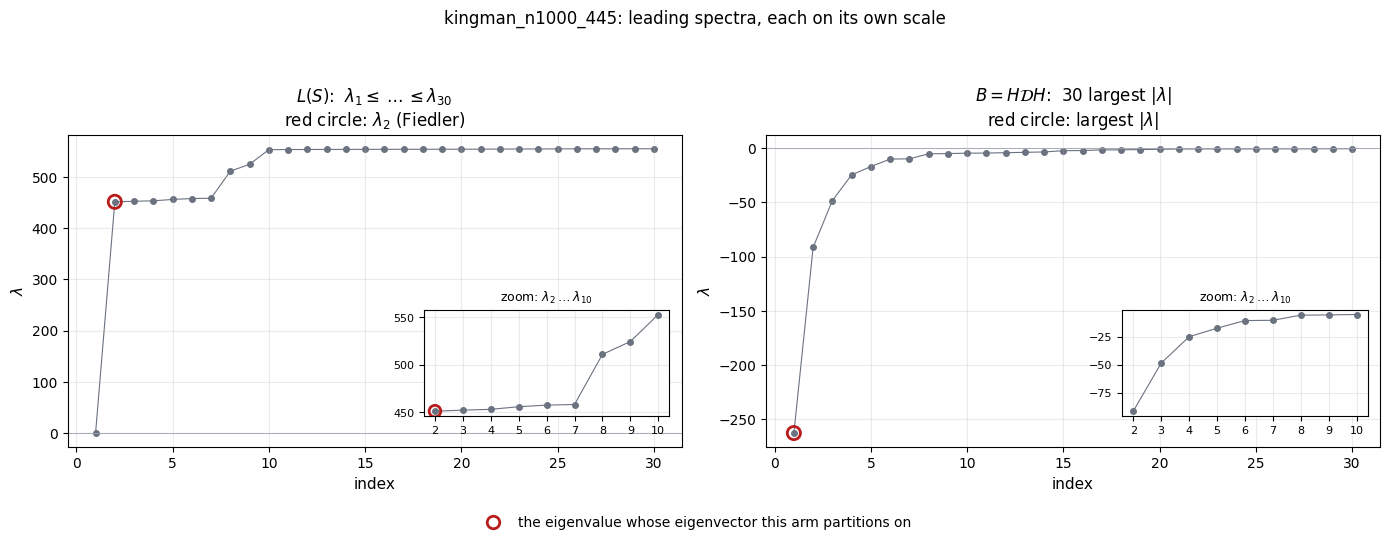

L(S): lambda_1..4  = [5.1416e-13 4.5127e+02 4.5234e+02 4.5319e+02]   relative gap (l3-l2)/l3 = 0.0024
B   : |lambda|_1..4 = [262.6286  91.5693  48.3633  24.6777]   relative gap = 0.6513


In [5]:
# The signal each arm actually has to work with: the first 50 eigenvalues of the two
# operators, ordered the way the arm reads them -- L(S) ascending (it wants the 2nd
# smallest, the Fiedler value) and B by |lambda| descending (it wants the largest,
# which for a raw distance matrix is the most negative). Two separate scales again:
# L(S) is PSD with a hard zero at index 1, B is negative semi-definite.
import scipy.linalg
from matplotlib.lines import Line2D

K = 50                                          # eigenvalues computed
K_PLOT = 30                                     # eigenvalues drawn
ev_L = scipy.linalg.eigvalsh(L_S, subset_by_index=[0, K - 1])          # ascending
ev_B = scipy.linalg.eigvalsh(B_mat)
ev_B = ev_B[np.argsort(-np.abs(ev_B))][:K]                             # |lambda| descending

# Both panels zoom on indices 2..10: for L(S) that is the Fiedler value and the gap
# above it, for B it is the tail the leading eigenvalue has to stand out from.
ZOOM = (1, 10)                                   # 0-based slice -> indices 2..10

# (values, index of the entry the arm uses, panel title, what the red circle marks)
spectra = [
    (ev_L, 1, rf"$L(S)$:  $\lambda_1 \leq \dots \leq \lambda_{{{K_PLOT}}}$",
     r"$\lambda_2$ (Fiedler)"),
    (ev_B, 0, rf"$B = H\mathcal{{D}}H$:  {K_PLOT} largest $|\lambda|$",
     r"largest $|\lambda|$"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, (ev, used, name, note) in zip(axes, spectra):
    ev, idx = ev[:K_PLOT], np.arange(1, K_PLOT + 1)
    ax.plot(idx, ev, "o-", ms=4, lw=0.8, color="#6b7280", zorder=1)
    ax.scatter([idx[used]], [ev[used]], s=90, facecolor="none",
               edgecolor="#b91c1c", lw=2, zorder=3)
    ax.axhline(0, color="#9ca3af", lw=0.6)
    ax.set_title(f"{name}\nred circle: {note}", fontsize=12)
    ax.set_xlabel("index", fontsize=11)
    ax.set_ylabel(r"$\lambda$", fontsize=11)
    ax.grid(alpha=0.25)

    # lambda_1 = 0 and the bulk sit orders of magnitude away from the gaps that
    # matter, so the head of each spectrum needs its own axis to be readable.
    a, b = ZOOM
    axi = ax.inset_axes([0.58, 0.10, 0.40, 0.34])   # flush bottom-right
    axi.plot(idx[a:b], ev[a:b], "o-", ms=4, lw=0.8, color="#6b7280")
    if a <= used < b:                            # B's leading value is outside the zoom
        axi.scatter([idx[used]], [ev[used]], s=70, facecolor="none",
                    edgecolor="#b91c1c", lw=2, zorder=3)
    axi.set_title(rf"zoom: $\lambda_{{{a+1}}}\dots\lambda_{{{b}}}$", fontsize=9)
    axi.set_xticks(np.arange(a + 1, b + 1))   # integer indices, not 2.5
    axi.tick_params(labelsize=8)
    axi.grid(alpha=0.25)

fig.legend([Line2D([], [], ls="none", marker="o", ms=9, mfc="none",
                   mec="#b91c1c", mew=2)],
           ["the eigenvalue whose eigenvector this arm partitions on"],
           loc="lower center", fontsize=10, frameon=False)
fig.suptitle(f"{TREE_ID}: leading spectra, each on its own scale", fontsize=12)
fig.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.show()

# The gap next to the eigenvector each arm uses is the whole story of how stable that
# split is: a small relative gap means sub-sampling can rotate the vector out of it.
gap_L = (ev_L[2] - ev_L[1]) / ev_L[2] if ev_L[2] > 0 else np.nan
gap_B = (abs(ev_B[0]) - abs(ev_B[1])) / abs(ev_B[0])
print(f"L(S): lambda_1..4  = {np.array2string(ev_L[:4], precision=4)}   "
      f"relative gap (l3-l2)/l3 = {gap_L:.4f}")
print(f"B   : |lambda|_1..4 = {np.array2string(np.abs(ev_B[:4]), precision=4)}   "
      f"relative gap = {gap_B:.4f}")


### Is that one tree representative?

The exhibit above is the **maximum-disagreement** tree in the Kingman pool (`argmax |log(eta_S / eta_B)|`), so it is by construction the least typical tree there is. This cell redraws the same two spectra for 100 random trees per model and asks whether the shape survives: is `L(S)` routinely near-degenerate at `lambda_2`, and is `B` routinely dominated by one `|lambda|`?

Cached to `notebooks_cache/eta_by_operator/`; ~2.6 s per tree, so ~9 min on a cold cache and instant afterwards.


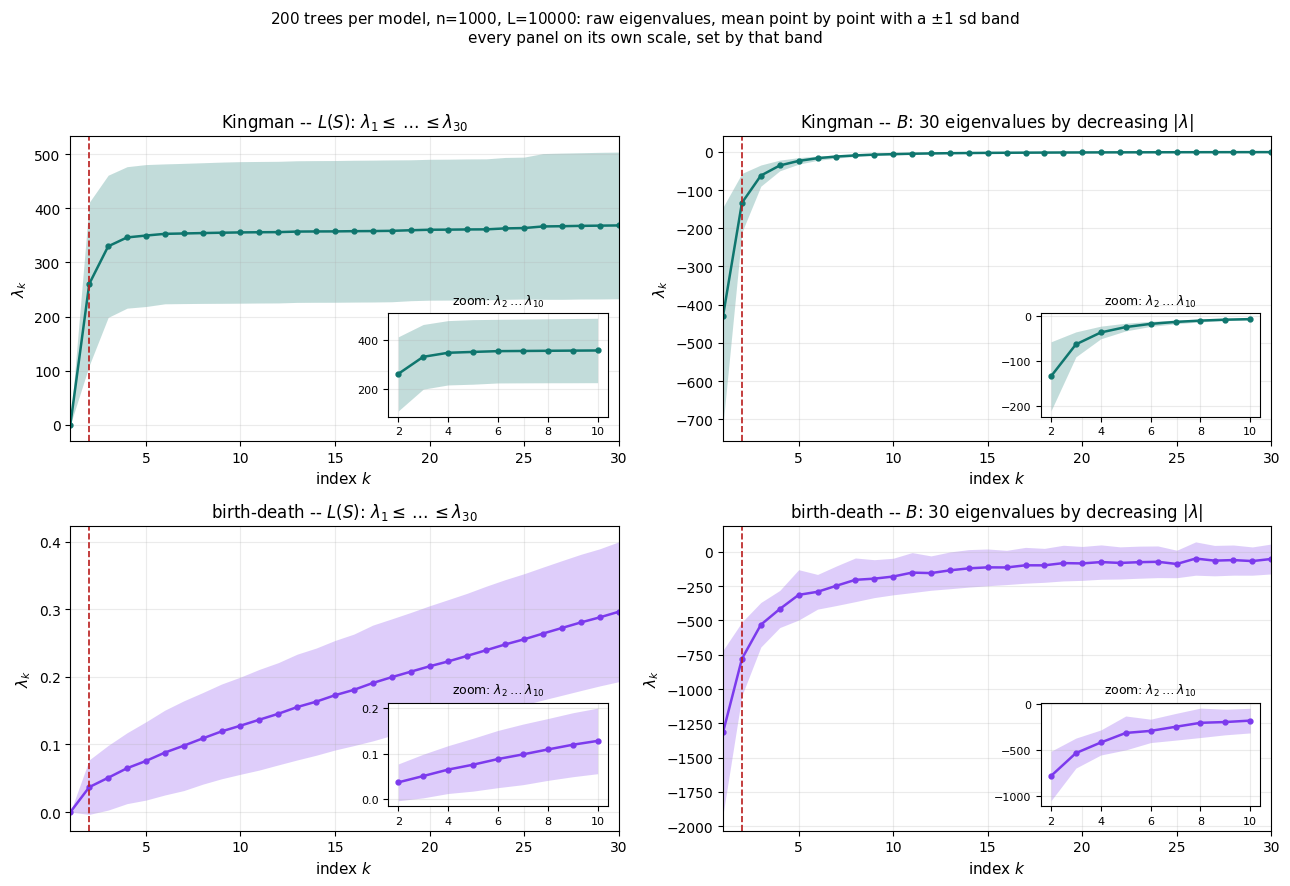

Kingman      median relative gap:  L(S) (l3-l2)/l3 = 0.196   B (|l1|-|l2|)/|l1| = 0.602   B wider in 92% of trees
birth-death  median relative gap:  L(S) (l3-l2)/l3 = 0.253   B (|l1|-|l2|)/|l1| = 0.375   B wider in 66% of trees


lambda_1 lambda_2 lambda_3 lambda_4 lambda_5
model       route                                                  
Kingman     L(S)      2.378e-13    244.2    323.1    342.3    352.7
            B = HDH      -352.1   -114.9   -55.76   -32.65   -22.52
birth-death L(S)     -1.407e-15  0.02595  0.03511  0.05277  0.06167
            B = HDH       -1201   -721.1   -500.1   -390.2   -316.7

In [6]:
# One tree proves nothing -- and this one is the worst possible witness, being the
# argmax-disagreement tree. Recompute both spectra on a random sample from BOTH pools
# and test the two claims the single exhibit suggests:
#   (i)  L(S) is near-degenerate at lambda_2 -- the Fiedler vector is not isolated, so
#        a sub-sample can rotate it into a different split;
#   (ii) B has one |lambda| far above the rest -- its leading vector IS isolated.
R_SAMPLE = 200                                  # trees per model
SPEC_CACHE = CDIR / f"spectra_sample_n{N}_L{SEQ_LEN}_R{R_SAMPLE}.npz"

rng = np.random.default_rng(0)
sample_ids = np.asarray(np.concatenate(
    [rng.choice(np.sort(df[df.model == mo]["tree"].values), R_SAMPLE, replace=False)
     for mo, _ in MODELS]), dtype="U")            # str dtype: the cache is pickle-free
models = np.repeat([mo for mo, _ in MODELS], R_SAMPLE)

cached = np.load(SPEC_CACHE, allow_pickle=False) if SPEC_CACHE.exists() else None
if cached is not None and np.array_equal(cached["ids"], sample_ids):
    spec_L, spec_B = cached["spec_L"], cached["spec_B"]
else:
    spec_L, spec_B = np.empty((sample_ids.size, K)), np.empty((sample_ids.size, K))
    for i, tid in enumerate(sample_ids):
        S_i, _, _, D_i = make_generated(str(tid), seq_len=SEQ_LEN)
        spec_L[i] = scipy.linalg.eigvalsh(compute_laplacian(S_i),
                                          subset_by_index=[0, K - 1])
        e = scipy.linalg.eigvalsh(griffing_centered(D_i))
        spec_B[i] = e[np.argsort(-np.abs(e))][:K]
        print(f"\r{i+1}/{sample_ids.size}  {tid}", end="")
    SPEC_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(SPEC_CACHE, ids=sample_ids, spec_L=spec_L, spec_B=spec_B)
    print()

# The two quantities the single exhibit made a claim about.
gapL = (spec_L[:, 2] - spec_L[:, 1]) / spec_L[:, 2]
gapB = (np.abs(spec_B[:, 0]) - np.abs(spec_B[:, 1])) / np.abs(spec_B[:, 0])
C_MOD = {"kingman": "#0f766e", "bd": "#7c3aed"}


def pad_lim(lohi, frac=0.06):
    """A y-range with a little air, so a clipped percentile band is not flush."""
    lo, hi = float(lohi[0]), float(lohi[1])
    pad = frac * (hi - lo) or 1e-12
    return lo - pad, hi + pad

# One panel per (tree model, operator): the two models' eigenvalues differ by orders
# of magnitude (Kingman similarities are far larger, so are its degrees), so putting
# them on one axis flattens birth-death onto the floor. Every panel scales itself.
kk = np.arange(1, K_PLOT + 1)
ARM_SPEC = [(spec_L[:, :K_PLOT],
             rf"$L(S)$: $\lambda_1 \leq \dots \leq \lambda_{{{K_PLOT}}}$", r"$\lambda_k$"),
            (spec_B[:, :K_PLOT],                # signed: B is NSD, so these are negative
             rf"$B$: {K_PLOT} eigenvalues by decreasing $|\lambda|$", r"$\lambda_k$")]

ZOOM_SAMPLE = (1, 10)                           # indices 2..10


def band(ax_, x, block, color):
    """Mean point by point, with a +/- 1 sd band around it.

    The individual curves hid the mean and dragged every axis out to a handful of
    extreme trees; the band carries the spread and sets an honest scale.
    """
    mu, sd = block.mean(axis=0), block.std(axis=0)
    ax_.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.25, lw=0)
    ax_.plot(x, mu, "o-", ms=3.5, lw=1.8, color=color)
    return float((mu - sd).min()), float((mu + sd).max())


fig, axes = plt.subplots(len(MODELS), len(ARM_SPEC), figsize=(13, 9))
for r, (mo, mname) in enumerate(MODELS):
    sel = models == mo
    for c, (Y, name, ylab) in enumerate(ARM_SPEC):
        ax, Yv = axes[r, c], Y[sel]
        ax.set_ylim(*pad_lim(band(ax, kk, Yv, C_MOD[mo])))
        ax.axvline(2, color="#b91c1c", ls="--", lw=1.2)
        ax.set_title(f"{mname} -- {name}", fontsize=12)
        ax.set_xlabel("index $k$", fontsize=11); ax.set_ylabel(ylab, fontsize=11)
        ax.set_xlim(1, K_PLOT)
        ax.grid(alpha=0.25)

        # same corner in all four panels, tighter window than the single-tree exhibit
        a, b = ZOOM_SAMPLE
        axi = ax.inset_axes([0.58, 0.08, 0.40, 0.34])   # flush bottom-right
        axi.set_ylim(*pad_lim(band(axi, kk[a:b], Yv[:, a:b], C_MOD[mo])))
        axi.set_title(rf"zoom: $\lambda_{{{a+1}}}\dots\lambda_{{{b}}}$", fontsize=9)
        axi.set_xticks(np.arange(a + 1, b + 1, 2))   # integers, thinned to fit
        axi.tick_params(labelsize=8)
        axi.grid(alpha=0.25)
fig.suptitle(f"{R_SAMPLE} trees per model, n={N}, L={SEQ_LEN}: raw eigenvalues, "
             f"mean point by point with a $\\pm$1 sd band\n"
             f"every panel on its own scale, set by that band", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# The head of each spectrum as numbers: one row per (tree model, route), one column
# per eigenvalue, median over the sample. B is NSD so its entries are negative, and
# L(S) has lambda_1 = 0 for every tree.
EV_TABLE_K = 5
ev_rows, ev_index = [], []
for mo, mname in MODELS:
    sel = models == mo
    for Y, rname in ((spec_L, "L(S)"), (spec_B, "B = HDH")):
        med = np.median(Y[sel, :EV_TABLE_K], axis=0)
        ev_rows.append({f"lambda_{j+1}": f"{med[j]:.4g}" for j in range(EV_TABLE_K)})
        ev_index.append((mname, rname))
ev_table = pd.DataFrame(ev_rows, index=pd.MultiIndex.from_tuples(
    ev_index, names=["model", "route"]))

# The one claim the band plot is here to settle, kept as a line rather than a table:
# how far the eigenvalue each arm reads sits from its neighbour.
for mo, mname in MODELS:
    sel = models == mo
    print(f"{mname:<12s} median relative gap:  L(S) (l3-l2)/l3 = {np.median(gapL[sel]):.3f}"
          f"   B (|l1|-|l2|)/|l1| = {np.median(gapB[sel]):.3f}"
          f"   B wider in {100*np.mean(gapB[sel] > gapL[sel]):.0f}% of trees")
ev_table   # medians over the sample; K_PLOT-wide version of these rows is the plot above

### The two leading eigenvalues, tree by tree

The band plot above averages the spectrum point by point. This one keeps the two
eigenvalues each route actually reads and shows their **distributions** over the same 200
trees per model — one panel per (model, route), `λ₁` in grey behind `λ₂` in the model
colour.

For `L(S)`, `λ₁ ≡ 0` on a connected graph, so that series is a spike at the left edge and
the content is `λ₂`, the Fiedler value. For `B` both are negative (`B` is NSD) and the
distance between the two clouds is the gap the sign rule depends on.

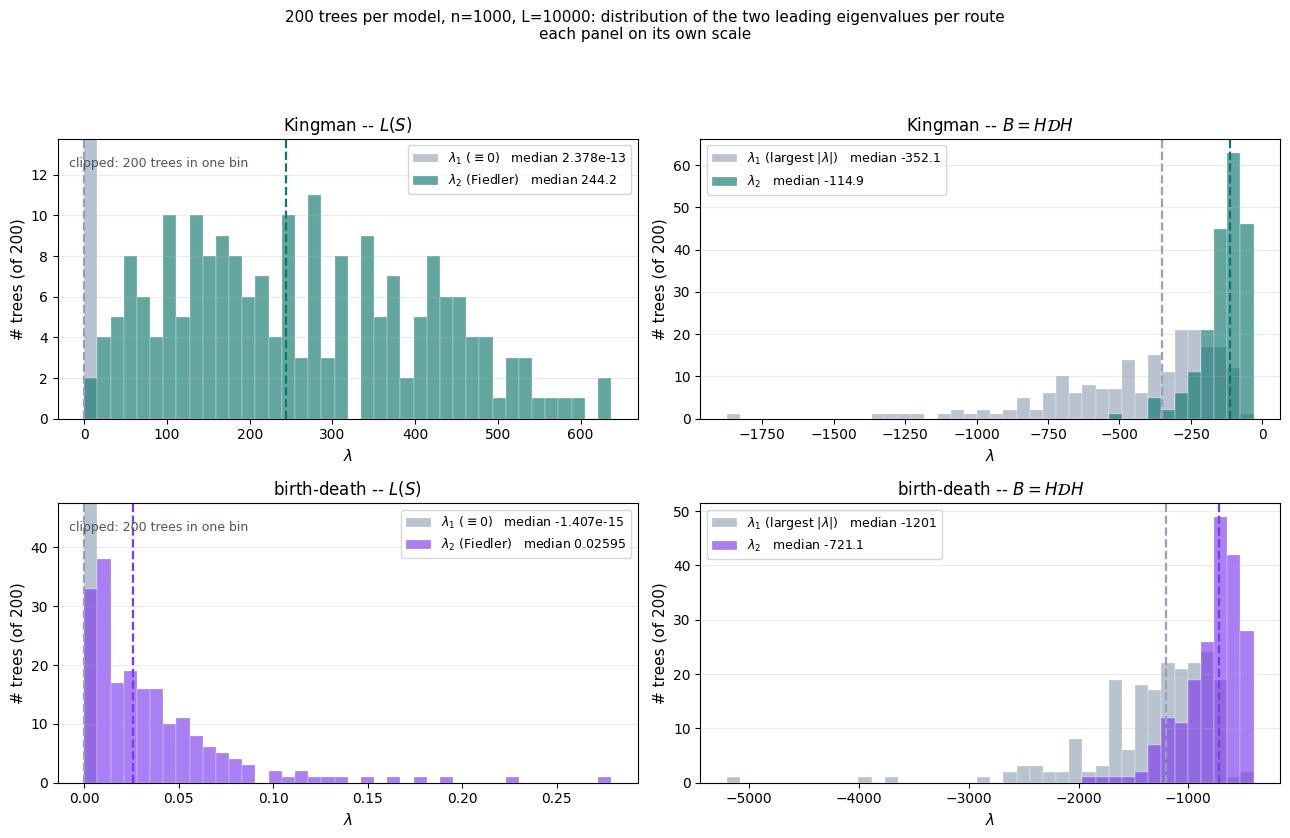

In [7]:
# The distribution of the two leading eigenvalues themselves, one panel per
# (tree model, route), on the same 200-tree sample as the band plot above. The band
# shows the mean shape; this shows how much every individual tree moves.
#   L(S): lambda_1 is identically 0 for a connected graph, so that series is a spike
#         at the left edge -- the informative one is lambda_2, the Fiedler value.
#   B   : the two largest |lambda|, and B is NSD, so both series are negative; the
#         separation between them IS the spectral gap the sign rule relies on.
# Every panel scales itself: Kingman degrees (hence L's eigenvalues) are four orders
# of magnitude above birth-death's, so one shared axis would flatten a whole row.
C_EV1 = "#94a3b8"                       # lambda_1 grey; lambda_2 takes the model colour
EV_SPEC = [(spec_L, r"$L(S)$", (r"$\lambda_1$ ($\equiv 0$)", r"$\lambda_2$ (Fiedler)")),
           (spec_B, r"$B = H\mathcal{D}H$",
            (r"$\lambda_1$ (largest $|\lambda|$)", r"$\lambda_2$"))]

fig, axes = plt.subplots(len(MODELS), len(EV_SPEC), figsize=(13, 8.5))
for r, (mo, mname) in enumerate(MODELS):
    sel = models == mo
    for c, (Y, rname, labels) in enumerate(EV_SPEC):
        ax = axes[r, c]
        e1, e2 = Y[sel, 0], Y[sel, 1]
        lo, hi_ = float(min(e1.min(), e2.min())), float(max(e1.max(), e2.max()))
        ebins = np.linspace(lo, hi_ + 1e-12 * max(abs(hi_), 1), 41)  # shared within panel
        peaks = []
        for ev, col, lab in ((e1, C_EV1, labels[0]), (e2, C_MOD[mo], labels[1])):
            cnt, _, _ = ax.hist(ev, bins=ebins, color=col, alpha=0.65,
                                edgecolor="white", lw=0.3,
                                label=f"{lab}   median {np.median(ev):.4g}")
            ax.axvline(float(np.median(ev)), color=col, ls="--", lw=1.6)
            peaks.append(int(cnt.max()))

        # L(S)'s lambda_1 is 0 for every tree, so its bar is the whole sample in one
        # bin and it flattens lambda_2 to nothing. Scale to the other series and say
        # in the axes how tall the clipped bar really is.
        tall, short = max(peaks), min(peaks)
        if tall > 4 * short:
            ax.set_ylim(0, short * 1.25)
            ax.annotate(f"clipped: {tall} trees in one bin", xy=(0.02, 0.90),
                        xycoords="axes fraction", fontsize=9, color="#4b5563")
        ax.set_title(f"{mname} -- {rname}", fontsize=12)
        ax.set_xlabel(r"$\lambda$", fontsize=11)
        ax.set_ylabel(f"# trees (of {int(sel.sum())})", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25, axis="y")
fig.suptitle(f"{R_SAMPLE} trees per model, n={N}, L={SEQ_LEN}: distribution of the two "
             f"leading eigenvalues per route\neach panel on its own scale", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### The vectors themselves

Same 200 trees per model, but now the object each route partitions on: the **Fiedler
vector** of `L(S)` and the **leading-|λ| vector** `u⁽¹⁾` of `B = HDH`. Every vector is
normalised to unit length, scaled by `√m` and oriented so the *minority* clan is on the
positive side, then all 200 × 1000 entries are pooled into one histogram per (model,
route).

On that scale a perfectly balanced, delocalised vector puts every entry near `±1`; a
localised one — the linear-algebra face of a large `η` — is a bulk pressed against `0`
with a few entries out at `√m ≈ 31`. The y-axis is logarithmic so that handful of far
entries is visible next to a bulk of a hundred thousand.

Cached to `notebooks_cache/eta_by_operator/`; ~17 min on a cold cache and instant
afterwards.

400/400  bd_n1000_7270_567


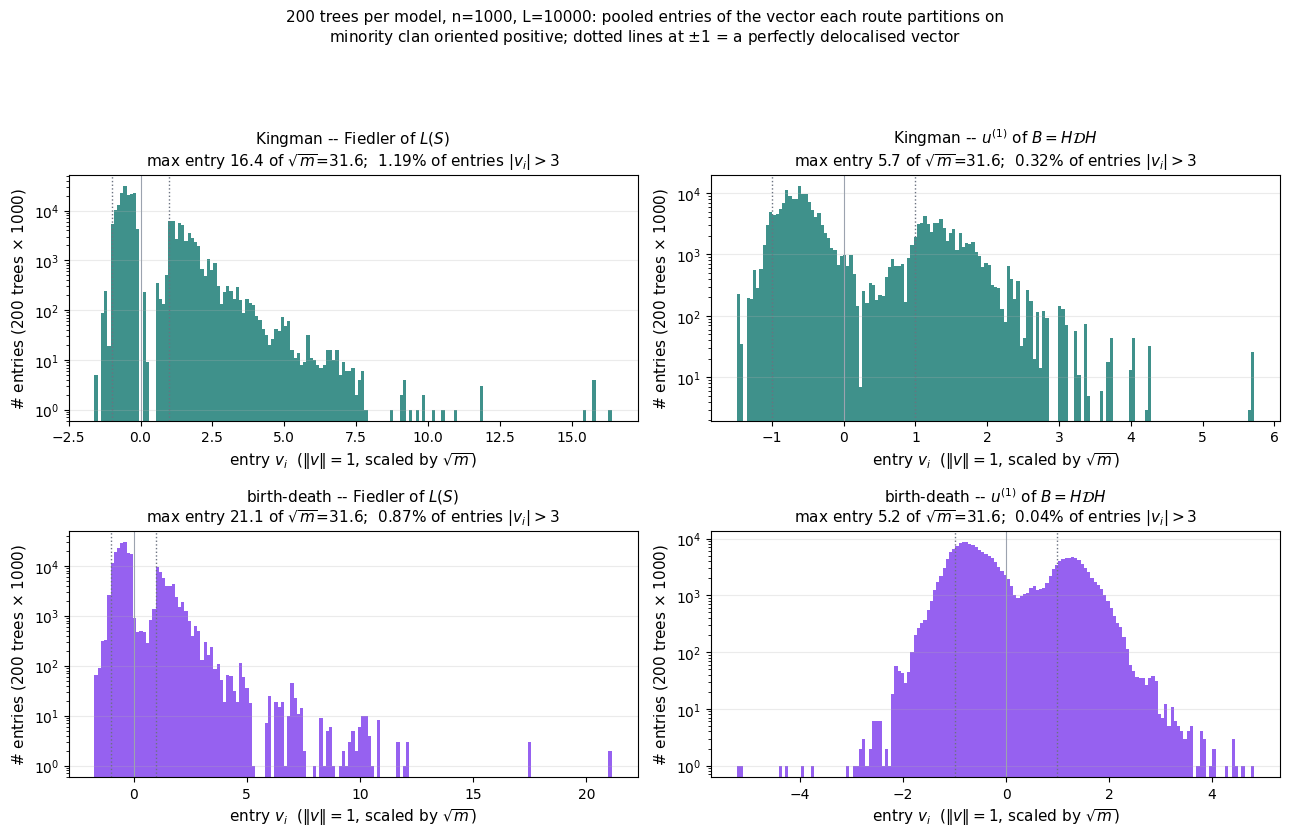

PR q25  PR med  PR q75 PR < 0.1
model       vector                                                       
Kingman     Fiedler of L(S)                0.149   0.382   0.649      20%
            u^{(1)} of B = H\mathcal{D}H   0.366   0.585   0.781       2%
birth-death Fiedler of L(S)                0.156   0.393   0.706      18%
            u^{(1)} of B = H\mathcal{D}H   0.456   0.602   0.725       0%

In [8]:
# The vectors, not their eigenvalues. Same sample_ids as the spectra cache, so every
# figure in this section is on the same trees. Two conventions, both applied per tree:
#   normalise to ||v||=1 and multiply by sqrt(m) -- an entry is then O(1) for a
#     delocalised vector at ANY m, so pooling across trees is meaningful;
#   orient so the minority clan is positive -- k-means labels are arbitrary and an
#     eigenvector's sign is arbitrary, so without this the pooled histogram is
#     symmetric by construction and says nothing.
VEC_CACHE = CDIR / f"vectors_sample_n{N}_L{SEQ_LEN}_R{R_SAMPLE}.npz"


def orient_minority(v, part):
    """Unit norm, scaled by sqrt(m), minority clan on the positive side."""
    v, part = orient(v, part)                     # part == True is now the minority
    if v[part].mean() < v[~part].mean():          # k-means labels carry no sign
        v = -v
    return v / np.linalg.norm(v) * np.sqrt(v.size)


cachedv = np.load(VEC_CACHE, allow_pickle=False) if VEC_CACHE.exists() else None
if cachedv is not None and np.array_equal(cachedv["ids"], sample_ids):
    vec_L, vec_B = cachedv["vec_L"], cachedv["vec_B"]
else:
    # float32: these feed a histogram, and it halves a cache that is committed
    vec_L = np.empty((sample_ids.size, N), dtype=np.float32)
    vec_B = np.empty_like(vec_L)
    for i, tid in enumerate(sample_ids):
        S_i, _, _, D_i = make_generated(str(tid), seq_len=SEQ_LEN)
        u = compute_fiedler_from_laplacian(compute_laplacian(S_i))
        vec_L[i] = orient_minority(
            u, np.asarray(_kmeans_bipartition(u, MIN_SPLIT)).astype(bool))
        w = griffing_leading_eigvec(D_i, solver="lm_k1")
        vec_B[i] = orient_minority(w, w >= 0)
        print(f"\r{i+1}/{sample_ids.size}  {tid}", end="")
    VEC_CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(VEC_CACHE, ids=sample_ids, vec_L=vec_L, vec_B=vec_B)
    print()

VEC_SPEC = [(vec_L, r"Fiedler of $L(S)$"), (vec_B, r"$u^{(1)}$ of $B = H\mathcal{D}H$")]
DELOC = 1.0                                     # entry value of a perfectly spread vector

fig, axes = plt.subplots(len(MODELS), len(VEC_SPEC), figsize=(13, 8.5))
for r, (mo, mname) in enumerate(MODELS):
    sel = models == mo
    for c, (V, vname) in enumerate(VEC_SPEC):
        ax, ent = axes[r, c], V[sel].ravel()
        ax.hist(ent, bins=161, color=C_MOD[mo], alpha=0.8, edgecolor="none")
        ax.set_yscale("log")                     # the tail is 1 entry against ~1e5
        for x in (-DELOC, DELOC):
            ax.axvline(x, color="#6b7280", ls=":", lw=1.0)
        ax.axvline(0, color="#9ca3af", lw=0.8)

        # how far from delocalised: the share of entries that a spread-out vector
        # would not have, and the single largest entry in the pool (sqrt(m) is the cap)
        big = float(np.mean(np.abs(ent) > 3 * DELOC))
        ax.set_title(f"{mname} -- {vname}\n"
                     f"max entry {np.abs(ent).max():.1f} of $\\sqrt{{m}}$="
                     f"{np.sqrt(N):.1f};  {100*big:.2f}% of entries $|v_i|>3$",
                     fontsize=11)
        ax.set_xlabel(r"entry $v_i$  ($\|v\|=1$, scaled by $\sqrt{m}$)", fontsize=11)
        ax.set_ylabel(f"# entries ({int(sel.sum())} trees $\\times$ {N})", fontsize=11)
        ax.grid(alpha=0.25, axis="y")
fig.suptitle(f"{R_SAMPLE} trees per model, n={N}, L={SEQ_LEN}: pooled entries of the "
             f"vector each route partitions on\nminority clan oriented positive; dotted "
             f"lines at $\\pm1$ = a perfectly delocalised vector", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# The same contrast as one number per tree: participation ratio PR = 1/(m * sum v_i^4)
# with the sqrt(m) scaling above, which is the fraction of leaves carrying the mass.
# PR near 1 is a vector spread over the whole tree; PR near 1/m is a vector living on
# a single leaf, i.e. the split that gives eta = m-1.
pr_rows = []
for mo, mname in MODELS:
    sel = models == mo
    for V, vname in VEC_SPEC:
        pr = 1.0 / np.mean((V[sel].astype(float) ** 2) ** 2, axis=1)   # in [1/m, 1]
        q = np.percentile(pr, [25, 50, 75])
        pr_rows.append({"model": mname, "vector": vname.replace("$", ""),
                        "PR q25": round(q[0], 3), "PR med": round(q[1], 3),
                        "PR q75": round(q[2], 3),
                        "PR < 0.1": f"{100*np.mean(pr < 0.1):.0f}%"})
pd.DataFrame(pr_rows).set_index(["model", "vector"])

/var/folders/k6/8drtl2312g793lb2vy4c83gc0000gn/T/ipykernel_71265/1789479195.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.04, 1, 0.95])


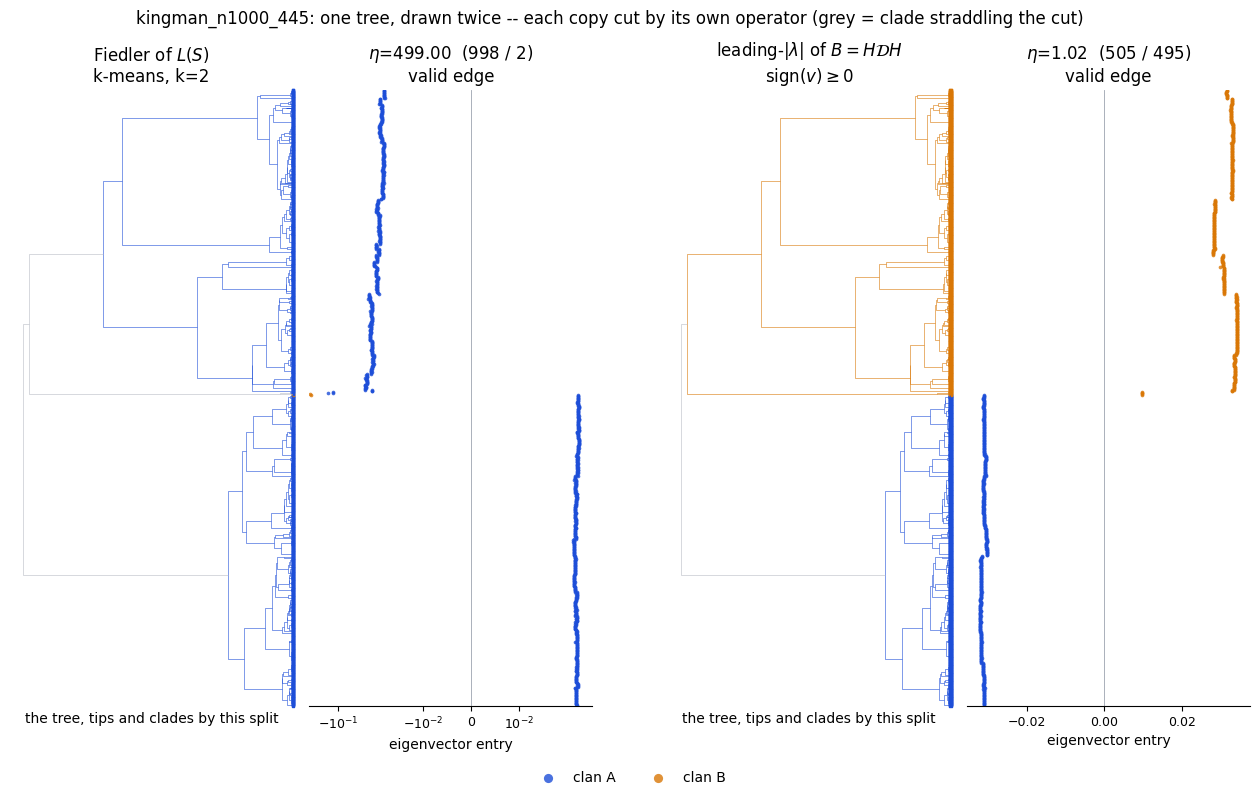

In [9]:
# One tree, drawn twice from its own patristic distances -- once per operator, with
# every clade coloured by the split that operator read off, and its vector alongside.
fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 0.15, 1, 1], wspace=0.07)
for pair, (v, part, opname, rule, tag) in zip((0, 3), [
        (v_S, part_S, r"Fiedler of $L(S)$", "k-means, k=2", "S"),
        (v_B, part_B, r"leading-$|\lambda|$ of $B=H\mathcal{D}H$", r"sign$(v)\geq 0$", "B")]):
    pt = part[sidx]                            # labels order -> tree order (linkage order)

    ax_t = fig.add_subplot(gs[pair])
    with plt.rc_context({"lines.linewidth": 0.4}):
        dendro = hierarchy.dendrogram(Z, ax=ax_t, orientation="left", no_labels=True,
                                      link_color_func=link_colors(Z, pt))
    leaf_order = np.asarray(dendro["leaves"])  # tree-leaf order -> bottom-to-top on screen
    ax_t.scatter(np.zeros(n_leaf), y, s=4, marker="s", clip_on=False,
                 c=np.where(pt[leaf_order], COL_B, COL_A))   # tip strip
    ax_t.set_ylim(0, 10 * n_leaf)
    ax_t.set_xticks([])
    ax_t.set_yticks([])
    for s in ax_t.spines.values():
        s.set_visible(False)
    ax_t.set_title(f"{opname}\n{rule}", fontsize=12)
    ax_t.set_xlabel("the tree, tips and clades by this split", fontsize=10)

    ax_v = fig.add_subplot(gs[pair + 1], sharey=ax_t)
    vv, pp = v[sidx][leaf_order], pt[leaf_order]
    for mask, col, name in ((~pp, COL_A, "clan A"), (pp, COL_B, "clan B")):
        ax_v.scatter(vv[mask], y[mask], s=7, c=col, linewidths=0, alpha=0.8, label=name)
    ax_v.axvline(0, color="#9ca3af", lw=0.6)
    ax_v.set_title(f"$\\eta$={row[f'eta_{tag}']:.2f}  "
                   f"({int((~pp).sum())} / {int(pp.sum())})\n"
                   f"{'valid edge' if row[f'valid_{tag}'] else 'NOT an edge'}", fontsize=12)
    ax_v.set_xlabel("eigenvector entry", fontsize=10)
    ax_v.tick_params(labelleft=False, labelsize=9)
    for s in ("top", "right", "left"):
        ax_v.spines[s].set_visible(False)
    # a few extreme entries would flatten the bulk onto one vertical line; symlog
    # keeps the bulk linear and compresses those into a tail, so the block
    # structure the rest of the vector carries stays visible
    lo, hi_ = np.percentile(vv, [1, 99])
    if np.ptp(vv) > 3 * (hi_ - lo):
        ax_v.set_xscale("symlog", linthresh=max(abs(lo), abs(hi_)), linscale=2.5)
    handles = ax_v.get_legend_handles_labels()

fig.legend(*handles, loc="lower center", ncol=2, fontsize=10, markerscale=2.5, frameon=False)
fig.suptitle(f"{TREE_ID}: one tree, drawn twice -- each copy cut by its own operator "
             f"(grey = clade straddling the cut)", fontsize=12)
fig.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

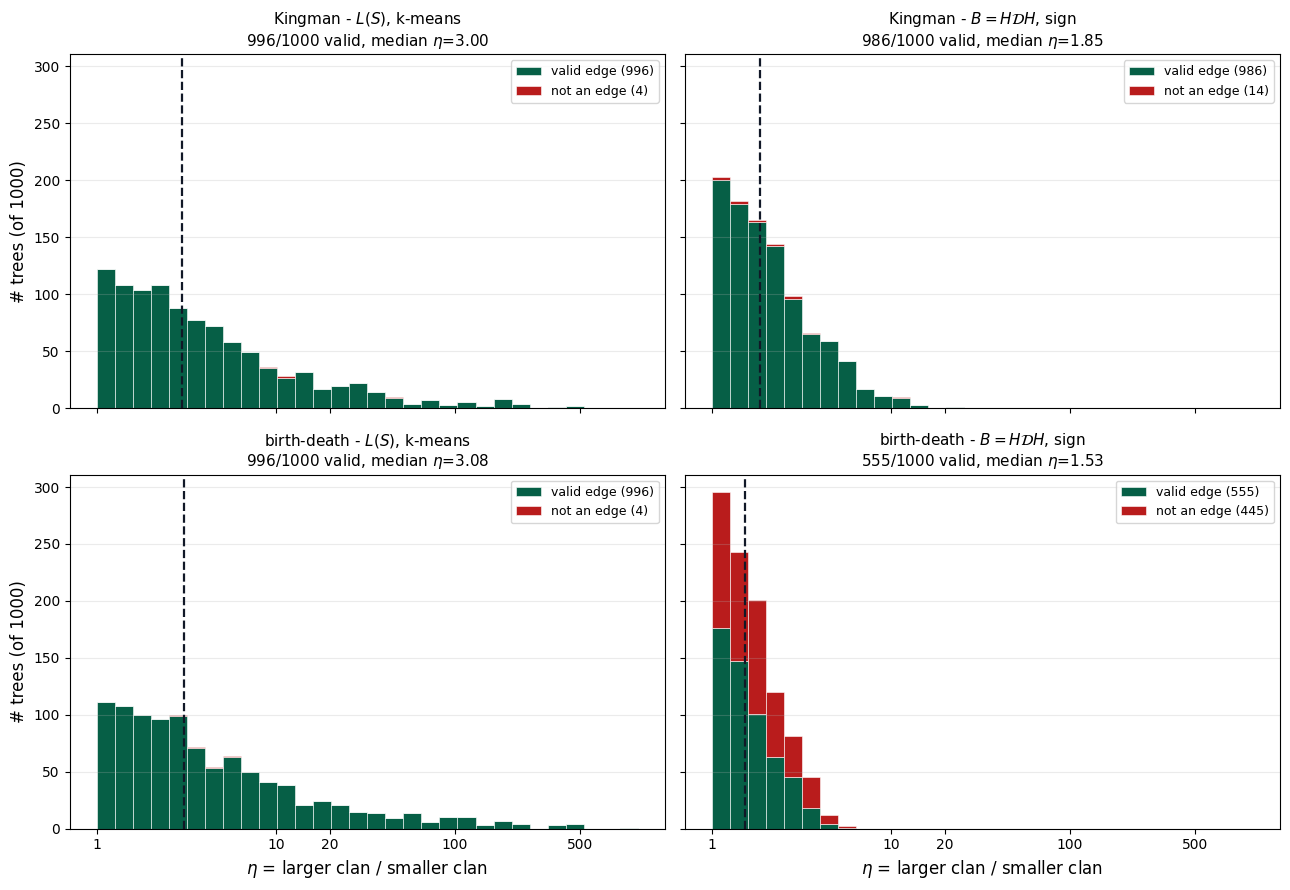

In [10]:
C_VALID, C_INVALID = "#065f46", "#b91c1c"     # green = real tree edge, red = not
XTICKS = [1, 10, 20, 100, 500]                # plain labels, not 10^k

hi = float(max(df["eta_S"].max(), df["eta_B"].max()))
bins = np.logspace(0, np.log10(hi * 1.05), 31)   # eta is a ratio spanning 1 .. ~n


def plain_log(axis, top=None):
    ticks = [t for t in XTICKS if t <= (top or hi) * 1.05]
    axis.set_major_locator(FixedLocator(ticks))
    axis.set_major_formatter(FixedFormatter([str(t) for t in ticks]))
    axis.set_minor_locator(FixedLocator([]))


fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for r, (model, mname) in enumerate(MODELS):
    d = df[df.model == model]
    for c, (tag, aname) in enumerate(ARMS):
        ax = axes[r, c]
        e, v = d[f"eta_{tag}"], d[f"valid_{tag}"]
        ax.hist([e[v], e[~v]], bins=bins, stacked=True,
                color=[C_VALID, C_INVALID], edgecolor="white", linewidth=0.4,
                label=[f"valid edge ({int(v.sum())})", f"not an edge ({int((~v).sum())})"])
        ax.axvline(float(e.median()), color="#111827", ls="--", lw=1.6)
        ax.set_xscale("log")
        plain_log(ax.xaxis)
        ax.set_title(f"{mname} - {aname}\n"
                     f"{int(v.sum())}/{len(d)} valid, median $\\eta$={e.median():.2f}",
                     fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25, axis="y")
        if r == 1:
            ax.set_xlabel(r"$\eta$ = larger clan / smaller clan", fontsize=12)
        if c == 0:
            ax.set_ylabel(f"# trees (of {len(d)})", fontsize=12)
fig.tight_layout()
plt.show()

In [11]:
for model, mname in MODELS:
    d = df[df.model == model]
    bs, bb = d["valid_S"], d["valid_B"]
    same = np.isclose(d["eta_S"], d["eta_B"])
    diff = d[~same]
    n_bal = int((diff["eta_B"] <= diff["eta_S"]).sum())
    print(f"--- {mname} ---")
    print(f"  both valid            : {int((bs & bb).sum()):4d}")
    print(f"  only L(S) valid       : {int((bs & ~bb).sum()):4d}")
    print(f"  only B valid          : {int((~bs & bb).sum()):4d}")
    print(f"  neither valid         : {int((~bs & ~bb).sum()):4d}")
    print(f"  same validity verdict : {100*(bs == bb).mean():.1f}%")
    print(f"  identical eta         : {100*same.mean():.1f}%  (same split picked by both)")
    print(f"  of {len(diff)} disagreements, B is the more balanced: {n_bal}/{len(diff)}")
    print()

--- Kingman ---
  both valid            :  982
  only L(S) valid       :   14
  only B valid          :    4
  neither valid         :    0
  same validity verdict : 98.2%
  identical eta         : 64.1%  (same split picked by both)
  of 359 disagreements, B is the more balanced: 355/359

--- birth-death ---
  both valid            :  553
  only L(S) valid       :  443
  only B valid          :    2
  neither valid         :    2
  same validity verdict : 55.5%
  identical eta         : 33.2%  (same split picked by both)
  of 668 disagreements, B is the more balanced: 654/668



## Paper figure

One PNG per panel, tiled in LaTeX as (a)-(d). **No matplotlib titles** — the `\subcaption`
carries model and operator. Type is sized for the printed scale: a 7in figure in a
`0.49\textwidth` subfigure is reduced ~0.46x, so anything under ~13pt lands under 6pt on
paper. All four panels share bins and axis limits, so the tails compare directly.

Set `FIG_DIR` to a scratch path to preview without overwriting the paper assets.

In [13]:
FIG_DIR = Path(os.environ.get(
    "FIG_DIR", _root / "docs" / "overleafs" / "v9" / "figures"))
FIG_DIR.mkdir(parents=True, exist_ok=True)

ymax = int(max(np.histogram(df[df.model == m][f"eta_{t}"], bins=bins)[0].max()
               for m, _ in MODELS for t, _ in ARMS) * 1.12)

for model, _ in MODELS:
    d = df[df.model == model]
    for tag, _ in ARMS:
        e, v = d[f"eta_{tag}"], d[f"valid_{tag}"]
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.hist([e[v], e[~v]], bins=bins, stacked=True,
                color=[C_VALID, C_INVALID], edgecolor="white", linewidth=0.4,
                label=[f"valid edge ({int(v.sum())})",
                       f"not an edge ({int((~v).sum())})"])
        ax.axvline(float(e.median()), color="#111827", ls="--", lw=2.2)
        ax.set_xscale("log")
        plain_log(ax.xaxis)
        ax.set_xlim(1, hi * 1.05)
        ax.set_ylim(0, ymax)
        ax.set_xlabel(r"$\eta$ = larger clan / smaller clan", fontsize=19)
        ax.set_ylabel(f"# trees (of {len(d)})", fontsize=19)
        ax.tick_params(labelsize=16)
        ax.legend(fontsize=15, loc="upper right", framealpha=0.95)
        ax.grid(alpha=0.25, axis="y")
        fig.tight_layout()
        name = f"eta_hist_{model}_{tag}.png"
        fig.savefig(FIG_DIR / name, dpi=170, bbox_inches="tight")
        plt.close(fig)
        print("wrote", name)

wrote eta_hist_kingman_S.png
wrote eta_hist_kingman_B.png
wrote eta_hist_bd_S.png
wrote eta_hist_bd_B.png


## Reading it

Rows are the tree model, columns the operator, on the *same* trees within each row. Green
is the part of each distribution that corresponds to a real tree edge; red is not an edge
and should be discounted entirely — a confident split onto a non-edge is worth nothing.

The scatter puts the two operators side by side per tree: points on the dotted diagonal
are trees where both chose the same split, points below it are trees where `B` chose the
more balanced one.

## Appendix figures for `distance-route-2`

The four exhibits above, re-emitted as paper assets for
`docs/overleafs/v9/distance-route-2/distance_route_abbe.tex`: **no matplotlib titles**
(the `\subcaption` carries panel identity), one PNG per panel, type sized for a
`0.49\textwidth` subfigure.

Set `FIG_DIR2` to a scratch path to preview without touching the manuscript assets.

In [ ]:
# Paper assets for distance-route-2. One PNG per panel, no titles anywhere -- the
# LaTeX subcaption names the panel and the caption carries the scaling.
#
# Type is sized in PRINTED points, not PNG points. Each panel goes into a subfigure
# of a known fraction of the 6.5in text block at `width=\textwidth`, so LaTeX reduces
# it by (cropped PNG width) / (fraction x 6.5) -- and `bbox_inches="tight"` crops by
# an amount that depends on the labels themselves, so that reduction is not known
# until the file exists. `emit` therefore draws twice: once to measure the crop, once
# with the sizes the measurement implies. Fixing this is what puts every panel of
# every figure on one physical type size; before it the tree panels printed at 12.8pt
# against the histograms' 9.5pt, off by a third within the same section.
from PIL import Image

FIG_DIR2 = Path(os.environ.get(
    "FIG_DIR2", _root / "docs" / "overleafs" / "v9" / "distance-route-2" / "figures"))
FIG_DIR2.mkdir(parents=True, exist_ok=True)

DPI = 170
TEXTW_IN = 6.5                              # \textwidth: 11pt article, 1in margins
LBL_PT, TCK_PT, CB_PT = 9.0, 7.5, 7.0       # printed sizes, the same in every panel


def emit(draw, name, figw, frac, pts):
    """Save ``draw(*sizes)`` so its type prints at ``pts`` in a frac*textwidth slot."""
    printed = frac * TEXTW_IN
    k = figw / printed                          # first guess: assume no crop
    for _ in range(2):
        fig = draw(*[p * k for p in pts])
        fig.savefig(FIG_DIR2 / name, dpi=DPI, bbox_inches="tight")
        plt.close(fig)
        k = Image.open(FIG_DIR2 / name).size[0] / DPI / printed
    print(f"wrote {name}  ->  {[round(p, 1) for p in pts]} pt printed")


from matplotlib.ticker import FormatStrFormatter, MaxNLocator

# (1) the tree, drawn once per operator with its vector alongside -- cell above, split
# into two files so LaTeX tiles them as (a) and (b).
def draw_tree_vec(v, part):
    def draw(LBL, TCK):
        fig, (ax_t, ax_v) = plt.subplots(
            1, 2, figsize=(7, 5.9), sharey=True,
            gridspec_kw={"width_ratios": [1, 1], "wspace": 0.04})
        pt = part[sidx]
        # heavier than the diagnostic copy: at this reduction a 0.4pt line vanishes
        with plt.rc_context({"lines.linewidth": 0.9}):
            dendro = hierarchy.dendrogram(Z, ax=ax_t, orientation="left", no_labels=True,
                                          link_color_func=link_colors(Z, pt))
        lo_ = np.asarray(dendro["leaves"])
        ax_t.scatter(np.zeros(n_leaf), y, s=7, marker="s", clip_on=False,
                     c=np.where(pt[lo_], COL_B, COL_A))
        ax_t.set_ylim(0, 10 * n_leaf)
        ax_t.set_xticks([]); ax_t.set_yticks([])
        for s in ax_t.spines.values():
            s.set_visible(False)

        vv, pp = v[sidx][lo_], pt[lo_]
        for mask, col in ((~pp, COL_A), (pp, COL_B)):
            ax_v.scatter(vv[mask], y[mask], s=11, c=col, linewidths=0, alpha=0.85)
        ax_v.axvline(0, color="#9ca3af", lw=0.6)
        ax_v.set_xlabel("eigenvector entry", fontsize=LBL)
        ax_v.locator_params(axis="x", nbins=4)      # symlog decades crowd at this size
        ax_v.tick_params(labelleft=False, labelsize=TCK)
        for s in ("top", "right", "left"):
            ax_v.spines[s].set_visible(False)
        lo, hi_ = np.percentile(vv, [1, 99])        # as in the diagnostic above
        if np.ptp(vv) > 3 * (hi_ - lo):
            ax_v.set_xscale("symlog", linthresh=max(abs(lo), abs(hi_)), linscale=2.5)
            # symlog puts a decade tick every factor of ten and they collide at this
            # size; the two extremes and zero are what the panel has to say
            ax_v.set_xticks([float(vv.min()), 0.0, float(vv.max())])
            ax_v.xaxis.set_major_formatter(FormatStrFormatter("%.2g"))
            ax_v.xaxis.set_minor_locator(FixedLocator([]))
        fig.tight_layout()
        return fig
    return draw


for v, part, tag in ((v_S, part_S, "S"), (v_B, part_B, "B")):
    emit(draw_tree_vec(v, part), f"dr2_tree_vec_{tag}.png",
         figw=7.0, frac=0.46, pts=(LBL_PT, TCK_PT))


# (2) the four matrices, one file each, leaves in tree order, each on its own scale.
def draw_matrix(A, cmap, norm):
    def draw(CBAR):
        fig, ax = plt.subplots(figsize=(6.4, 5.1))
        cm = plt.get_cmap(cmap).copy()
        cm.set_bad("#e5e7eb")
        im = ax.imshow(A[np.ix_(perm, perm)], cmap=cm, norm=norm,
                       interpolation="nearest", origin="upper")
        ax.set_xticks([]); ax.set_yticks([])
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cb.ax.tick_params(labelsize=CBAR)
        cb.ax.yaxis.set_major_locator(MaxNLocator(4))   # four labels fit at this width
        fig.tight_layout()
        return fig
    return draw


for key, A, _, _, cmap, norm in panels:
    emit(draw_matrix(A, cmap, norm), f"dr2_mat_{key}.png",
         figw=6.4, frac=0.24, pts=(CB_PT,))


# (3) the two leading eigenvalues over the pool, one file per (model, route).
def draw_eig(e1, e2, col2):
    def draw(LBL, TCK):
        lo, hi_ = float(min(e1.min(), e2.min())), float(max(e1.max(), e2.max()))
        ebins = np.linspace(lo, hi_ + 1e-12 * max(abs(hi_), 1), 41)
        fig, ax = plt.subplots(figsize=(7, 3.0))
        peaks = []
        for ev, col in ((e1, C_EV1), (e2, col2)):
            cnt, _, _ = ax.hist(ev, bins=ebins, color=col, alpha=0.65,
                                edgecolor="white", lw=0.3)
            ax.axvline(float(np.median(ev)), color=col, ls="--", lw=2.2)
            peaks.append(int(cnt.max()))
        if max(peaks) > 4 * min(peaks):          # L(S): lambda_1 = 0 for every tree
            ax.set_ylim(0, min(peaks) * 1.25)
        ax.set_xlabel(r"$\lambda$", fontsize=LBL)
        ax.set_ylabel("# trees", fontsize=LBL)   # the count is in the caption
        ax.tick_params(labelsize=TCK)
        ax.grid(alpha=0.25, axis="y")
        fig.tight_layout()
        return fig
    return draw


for mo, _ in MODELS:
    sel = models == mo
    for Y, key in ((spec_L, "L"), (spec_B, "B")):
        emit(draw_eig(Y[sel, 0], Y[sel, 1], C_MOD[mo]), f"dr2_eig_{mo}_{key}.png",
             figw=7.0, frac=0.42, pts=(LBL_PT, TCK_PT))


# (4) the classification vectors: pooled entries, one file per (model, route).
def draw_vec(ent, col):
    def draw(LBL, TCK):
        fig, ax = plt.subplots(figsize=(7, 3.0))
        ax.hist(ent, bins=161, color=col, alpha=0.8, edgecolor="none")
        ax.set_yscale("log")
        for x in (-DELOC, DELOC):
            ax.axvline(x, color="#6b7280", ls=":", lw=1.4)
        ax.axvline(0, color="#9ca3af", lw=0.8)
        ax.set_xlabel(r"entry $\sqrt{m}\, v_i$", fontsize=LBL)
        ax.set_ylabel("# entries", fontsize=LBL)
        ax.tick_params(labelsize=TCK)
        ax.grid(alpha=0.25, axis="y")
        fig.tight_layout()
        return fig
    return draw


for mo, _ in MODELS:
    sel = models == mo
    for V, key in ((vec_L, "L"), (vec_B, "B")):
        emit(draw_vec(V[sel].ravel(), C_MOD[mo]), f"dr2_vec_{mo}_{key}.png",
             figw=7.0, frac=0.42, pts=(LBL_PT, TCK_PT))
